A fictional online retail store ran a 4-week A/B test (6 Jan – 2 Feb 2025) to measure whether a redesigned product page increased purchases.
kpi-

Goal is to
1. Determine the page with higher  1
2. The page with more time spent  3
3. With more products added to cart 2
4. More returning vistors 5
5. With higher number of pages viewed 4

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [9]:
df =pd.read_csv('ab_test_ecommerce.csv', parse_dates =['session_date'])

In [ ]:
df.info()

EXPLORATORY DATA ANALYSIS

In [ ]:
# Check for missing values
print(df.isnull().sum())

In [14]:
#check fo duplicates at  using  user_id as the unique identifier for each session
duplicates = df.duplicated(subset=['user_id']).sum()
print(f'Number of duplicate user_id entries: {duplicates}')

Number of duplicate user_id entries: 0


ENABLE TIME INTELLIGENCE

In [15]:
from datetime import timedelta

max_date = df['session_date'].max()
min_date = df['session_date'].min()
print(f'Max date: {max_date}')  
print(f'Min date: {min_date}')
print(f'Duration of the test: {max_date - min_date}')

Max date: 2025-02-02 23:48:00
Min date: 2025-01-06 00:09:00
Duration of the test: 27 days 23:39:00


In [16]:
# cross tab control and test groups
df['group'].unique()

<StringArray>
['A', 'B']
Length: 2, dtype: str

SAMPLING

In [19]:
control_group = df[df['group'] == 'A'].sample(n=2500, random_state=42)
test_group = df[df['group'] == 'B'].sample(n=2500, random_state=42)

In [20]:
ab_test = pd.concat([control_group, test_group], axis=0)
ab_test.reset_index(drop=True, inplace=True)

In [ ]:
ab_test.info()

In [22]:
ab_test.group.value_counts()

group
A    2500
B    2500
Name: count, dtype: int64

In [44]:
import numpy as np
import scipy.stats as stats
std= lambda x: np.std(x, ddof=0)
ste = lambda x: stats.sem(x, ddof=0)
conversion_summary = ab_test.groupby('group')['converted'].agg([np.mean, std, ste])
conversion_summary.columns = ['conversion_rate', 'std_dev', 'std_error']
print(conversion_summary)





       conversion_rate   std_dev  std_error
group                                      
A               0.0912  0.287893   0.005758
B               0.1192  0.324024   0.006480


TESTING HYPOTHESIS
alpha or significance level is 0.05
Null hypothesis: There is no singnificant difference in conversion rate between control and test group
Alternate hypothesis: The is significant difference in conversion reate between control and test group.

In [45]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
control_results = ab_test[ab_test['group'] == 'A']['converted']
test_results = ab_test[ab_test['group'] == 'B']['converted']

In [46]:
n_control = control_results.count()
n_test = test_results.count()
successes =[control_results.sum(), test_results.sum()]
n_obs = [n_control, n_test]
z_stat, p_value = proportions_ztest(successes, n_obs)
print(f'Z-statistic: {z_stat:.4f}') 
print(f'P-value: {p_value:.4f}')
lower_con, upper_con = proportion_confint(successes[0], n_obs[0], method="normal")
lower_treat, upper_treat = proportion_confint(successes[1], n_obs[1], method="normal")
print(f'ci 95% for control group: [{lower_con:.3f}, {upper_con:.3f}]')
print(f'ci 95% for treatment group: [{lower_treat:.3f}, {upper_treat:.3f}]')

Z-statistic: -3.2266
P-value: 0.0013
ci 95% for control group: [0.080, 0.102]
ci 95% for treatment group: [0.106, 0.132]


In [47]:
#TESTING HYPOTHESIS
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in conversion rates between the control and treatment groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in conversion rates between the control and treatment groups.")

Reject the null hypothesis: There is a significant difference in conversion rates between the control and treatment groups.


Descriptive statistics


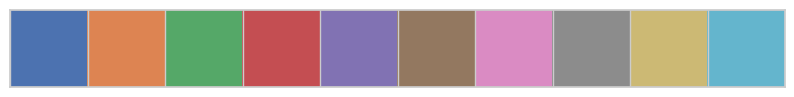

In [80]:
current_palette = sns.color_palette()
sns.palplot(current_palette)
sns.set_style('whitegrid')
sns.set_palette('pastel')
sns.set(color_codes=True)

In [49]:
# comparing revenue between the two groups
revenue_summary = ab_test.groupby('group')['revenue_usd'].agg(sum).reset_index()
revenue_summary.columns = ['group', 'total_revenue']
print(revenue_summary)


  group  total_revenue
0     A       18687.45
1     B       23819.25


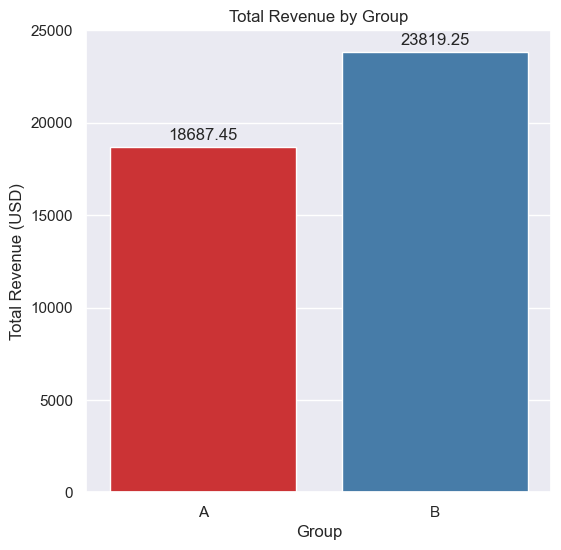

In [81]:
# visualize revenue btween the two product pages
bar_chart =sns.barplot(x='group', y='total_revenue', data=revenue_summary, hue='group', palette='Set1')
bar_chart.bar_label(bar_chart.containers[0], fmt='%.2f', padding=3)
bar_chart.bar_label(bar_chart.containers[1], fmt='%.2f', padding=3)
#plt.legend(title='Group')
#plt.figure(figsize=(9, 9))
plt.title('Total Revenue by Group')
plt.xlabel('Group') 
plt.ylabel('Total Revenue (USD)')
plt.show()


Since there is significance in conversion rate I will dive deeper into descriptive analysis of control group

In [62]:
ab_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               5000 non-null   str           
 1   session_date          5000 non-null   datetime64[us]
 2   group                 5000 non-null   str           
 3   age                   5000 non-null   int64         
 4   gender                5000 non-null   str           
 5   device_type           5000 non-null   str           
 6   traffic_source        5000 non-null   str           
 7   is_returning_visitor  5000 non-null   int64         
 8   time_on_page_seconds  5000 non-null   float64       
 9   pages_visited         5000 non-null   int64         
 10  added_to_cart         5000 non-null   int64         
 11  converted             5000 non-null   int64         
 12  revenue_usd           5000 non-null   float64       
dtypes: datetime64[us](1), float64

In [65]:
Gender_Revenue_test_group = ab_test[ab_test['group'] == 'A'].groupby(['gender'])['revenue_usd'].agg(sum).reset_index()
Gender_Revenue_test_group.columns=['gender','total_revenue']
print(Gender_Revenue_test_group)

             gender  total_revenue
0            Female        9454.95
1              Male        8770.89
2  Non-binary/Other         461.61


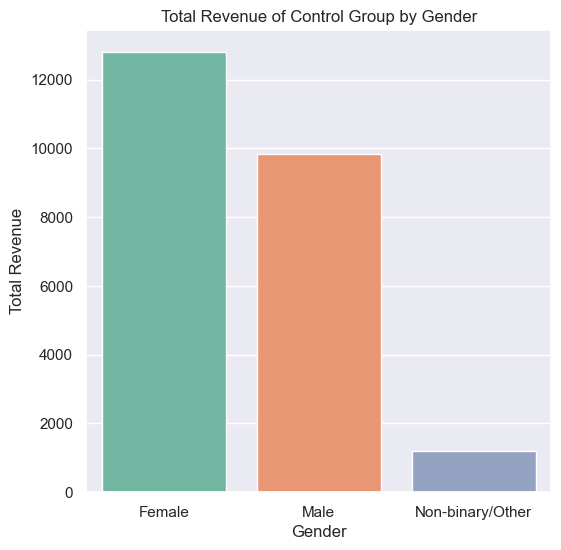

In [83]:
Gender_Revenue_t=sns.barplot(x='gender', y='total_revenue', data=Gender_Revenue_test_group, hue='gender', palette='Set2',native_scale=2)
Gender_Revenue_t.bar_label(bar_chart.containers[0], fmt='%.2f', padding=3)
Gender_Revenue_t.bar_label(bar_chart.containers[1], fmt='%.2f', padding=3)


plt.title('Total Revenue of Control Group by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.show()


In [73]:
Gender_Revenue_test_group = ab_test[ab_test['group'] == 'B'].groupby(['gender'])['revenue_usd'].agg(sum).reset_index()
Gender_Revenue_test_group.columns=['gender','total_revenue']
print(Gender_Revenue_test_group)

             gender  total_revenue
0            Female       12798.23
1              Male        9835.52
2  Non-binary/Other        1185.50


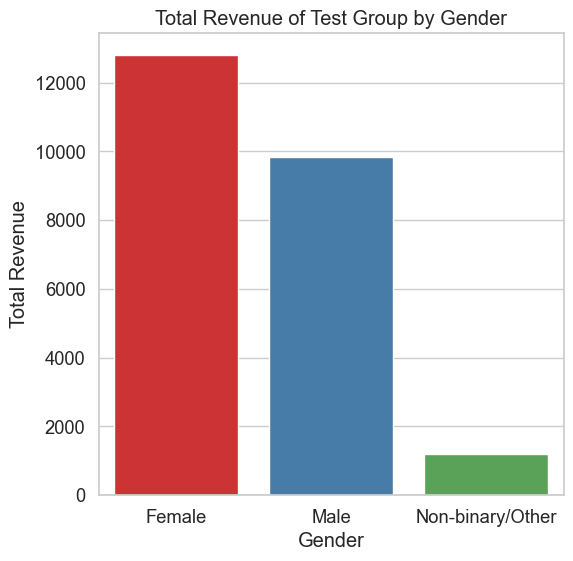

In [86]:
Gender_Revenue_t=sns.barplot(x='gender', y='total_revenue', data=Gender_Revenue_test_group, hue='gender', palette='Set1',native_scale=2)
Gender_Revenue_t.bar_label(bar_chart.containers[0], fmt='%.2f', padding=3)
Gender_Revenue_t.bar_label(bar_chart.containers[1], fmt='%.2f', padding=3)
#sns.set_theme(color_codes=True, style='whitegrid', font_scale=1.2, rc={'figure.figsize':(6,6)})

plt.title('Total Revenue of Test Group by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.show()


DEVICE

In [87]:
ab_test['device_type'].unique()

<StringArray>
['mobile', 'tablet', 'desktop']
Length: 3, dtype: str

In [88]:
Device_Revenue_test_group = ab_test[ab_test['group'] == 'B'].groupby(['device_type'])['revenue_usd'].agg(sum).reset_index()
Device_Revenue_test_group.columns=['device_type','total_revenue']
print(Device_Revenue_test_group)

  device_type  total_revenue
0     desktop        8725.41
1      mobile       12755.60
2      tablet        2338.24


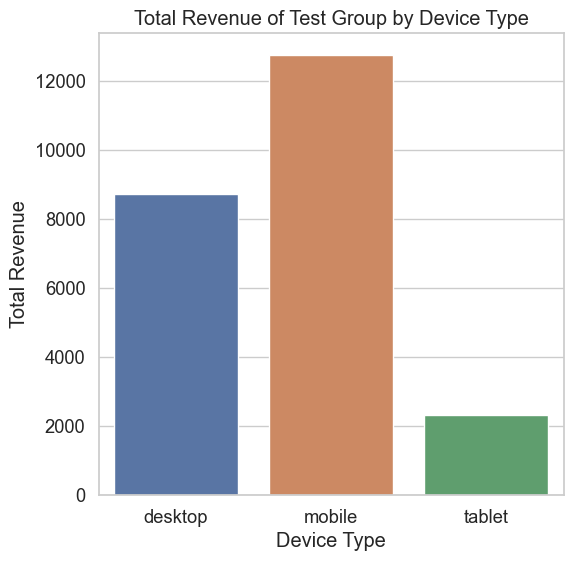

In [ ]:
Device_Revenue_control_group = ab_test[ab_test['group'] == 'A'].groupby(['device_type'])['revenue_usd'].agg(sum).reset_index()
Device_Revenue_control_group.columns=['device_type','total_revenue']
print(Device_Revenue_control_group)

In [91]:
Device_Revenue_control_group = ab_test[ab_test['group'] == 'A'].groupby(['device_type'])['revenue_usd'].agg(sum).reset_index()
Device_Revenue_control_group.columns=['device_type','total_revenue']
print(Device_Revenue_control_group)

  device_type  total_revenue
0     desktop        9070.83
1      mobile        7935.34
2      tablet        1681.28


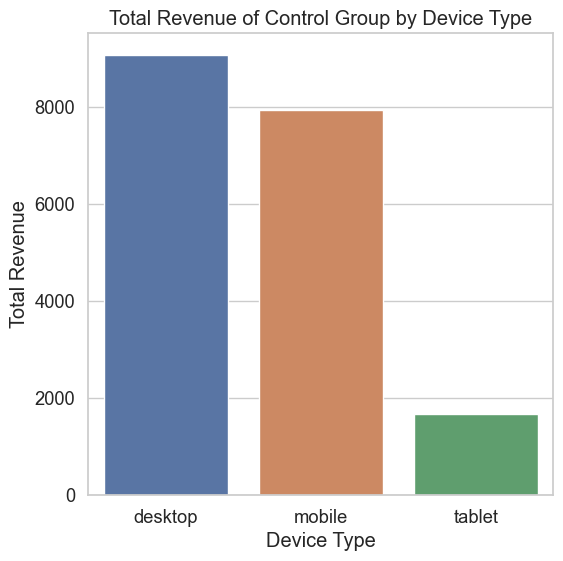

In [92]:
Device_Revenue_t=sns.barplot(x='device_type', y='total_revenue', data=Device_Revenue_control_group, hue='device_type')
Device_Revenue_t.bar_label(bar_chart.containers[0], fmt='%.2f', padding=3)

#sns.set_theme(color_codes=True, style='whitegrid', font_scale=1.2, rc={'figure.figsize':(6,6)})

plt.title('Total Revenue of Control Group by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Total Revenue')
plt.show()


chi_square test to confirm if there is relationship between sex and device type

In [96]:
#cont
contigency_table_control = pd.crosstab(ab_test[ab_test['group'] == 'A']['gender'], ab_test[ab_test['group'] == 'A']['device_type'])
contigency_table_control

device_type,desktop,mobile,tablet
gender,,,
Female,425,661,136
Male,428,661,125
Non-binary/Other,26,33,5


In [98]:
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contigency_table_control)
print(f'Chi-squared statistic: {chi2:.4f}')
print(f'P-value: {p:.4f}')

Chi-squared statistic: 1.5862
P-value: 0.8113


In [99]:
# test null hypothesis
if p < 0.05:
    print("Reject the null hypothesis: There is a significant association between gender and device type in the control group.") 
else:
    print("Fail to reject the null hypothesis: There is no significant association between gender and device type in the control group.")

Fail to reject the null hypothesis: There is no significant association between gender and device type in the control group.


In [100]:
#cont
contigency_table_test = pd.crosstab(ab_test[ab_test['group'] == 'B']['gender'], ab_test[ab_test['group'] == 'B']['device_type'])
contigency_table_test

device_type,desktop,mobile,tablet
gender,,,
Female,451,678,122
Male,405,633,131
Non-binary/Other,29,40,11


In [102]:
chi2, p, dof, expected = chi2_contingency(contigency_table_test)
print(f'Chi-squared statistic: {chi2:.4f}')
print(f'P-value: {p:.4f}')

Chi-squared statistic: 2.6104
P-value: 0.6250


In [103]:
# test null hypothesis
if p < 0.05:
    print("Reject the null hypothesis: There is a significant association between gender and device type in the control group.") 
else:
    print("Fail to reject the null hypothesis: There is no significant association between gender and device type in the control group.")

Fail to reject the null hypothesis: There is no significant association between gender and device type in the control group.


In [104]:
Traffic_Revenue_control_group = ab_test[ab_test['group'] == 'A'].groupby(['traffic_source'])['revenue_usd'].agg(sum).reset_index()
Traffic_Revenue_control_group.columns=['traffic_source','total_revenue']
print(Traffic_Revenue_control_group)

   traffic_source  total_revenue
0          direct        1649.42
1           email        4638.50
2  organic_search        5692.25
3         paid_ad        4670.07
4    social_media        2037.21


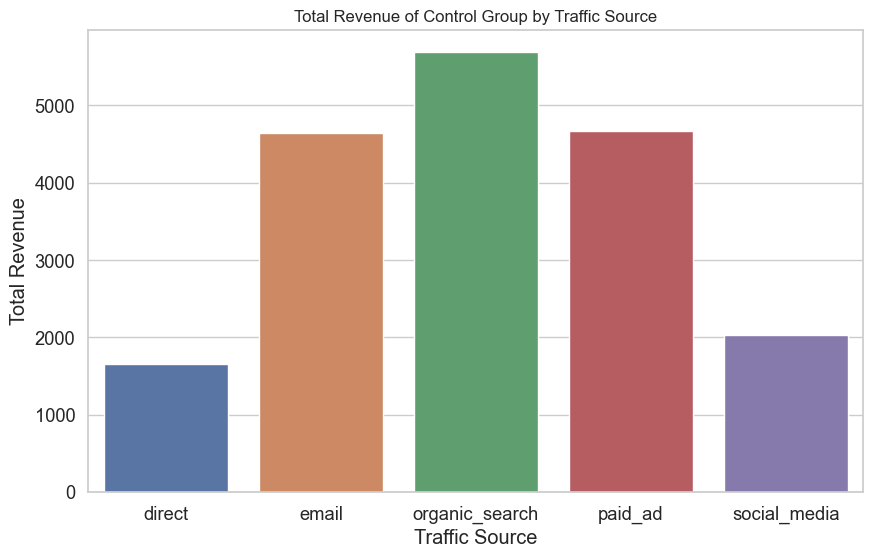

In [108]:
Traffic_Revenue_t=sns.barplot(x='traffic_source', y='total_revenue', data=Traffic_Revenue_control_group, hue='traffic_source')
Traffic_Revenue_t.bar_label(bar_chart.containers[0], fmt='%.2f', padding=3)

sns.set_theme(color_codes=True, style='whitegrid', font_scale=1.0, rc={'figure.figsize':(10,6)})

plt.title('Total Revenue of Control Group by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Total Revenue')
plt.show()


In [110]:
Traffic_Revenue_test_group = ab_test[ab_test['group'] == 'B'].groupby(['traffic_source'])['revenue_usd'].agg(sum).reset_index()
Traffic_Revenue_test_group.columns=['traffic_source','total_revenue']
print(Traffic_Revenue_test_group)

   traffic_source  total_revenue
0          direct        2150.60
1           email        5914.91
2  organic_search        6180.61
3         paid_ad        7226.84
4    social_media        2346.29


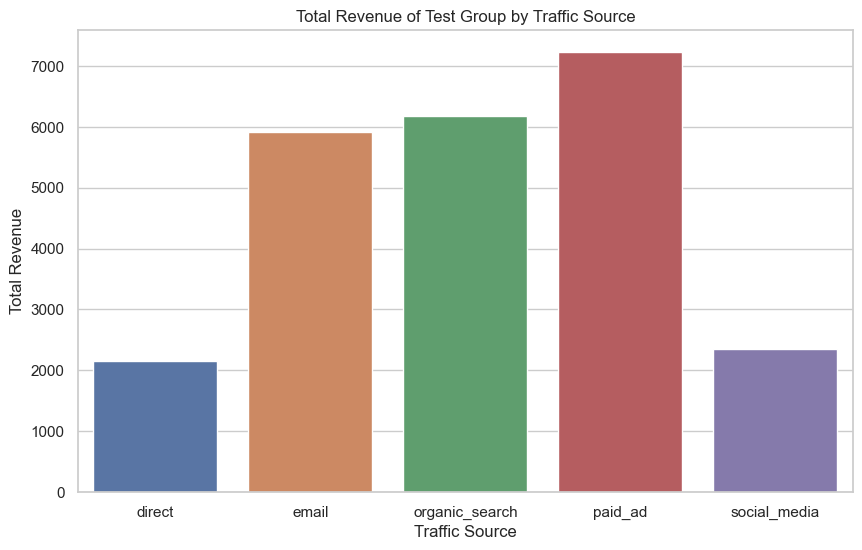

In [111]:
Traffic_Revenue_t=sns.barplot(x='traffic_source', y='total_revenue', data=Traffic_Revenue_test_group, hue='traffic_source')
Traffic_Revenue_t.bar_label(bar_chart.containers[0], fmt='%.2f', padding=3)

sns.set_theme(color_codes=True, style='whitegrid', font_scale=1.0, rc={'figure.figsize':(10,6)})

plt.title('Total Revenue of Test Group by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Total Revenue')
plt.show()


In [ ]:
#chi_square of traffic source and device type for control# group
contigency_table_control_dt = pd.crosstab(ab_test[ab_test['group'] == 'B']['traffic_source'], ab_test[ab_test['group'] == 'B']['device_type'])
print(contigency_table_control_dt)

device_type     desktop  mobile  tablet
traffic_source                         
direct               90     132      20
email               177     262      71
organic_search      249     411      74
paid_ad             240     348      63
social_media        129     198      36


In [117]:
chi2, p, dof, expected = chi2_contingency(contigency_table_control_dt)
print(f'Chi-squared statistic: {chi2:.4f}')    
print(f'P-value: {p:.4f}')

Chi-squared statistic: 9.8440
P-value: 0.2761


In [118]:
#Chi_square of traffic source and gender for test group
contigency_table_test_gt = pd.crosstab(ab_test[ab_test['group'] == 'B']['traffic_source'], ab_test[ab_test['group'] == 'B']['gender'])  
chi2, p, dof, expected = chi2_contingency(contigency_table_test_gt)
print(f'Chi-squared statistic: {chi2:.4f}')    
print(f'P-value: {p:.4f}') 

Chi-squared statistic: 7.5942
P-value: 0.4741


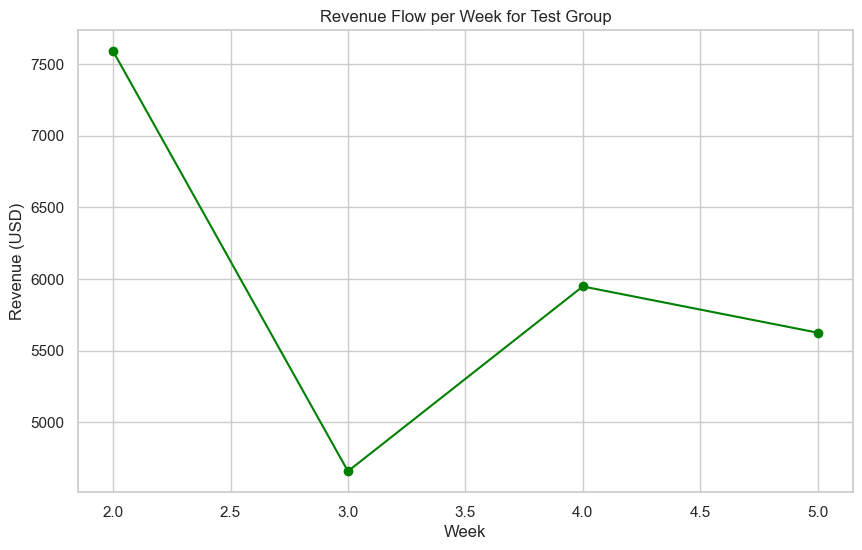

In [126]:
#flow of revenue per week for control group
ab_test['week'] = ab_test['session_date'].dt.isocalendar().week
revenue_by_week_control = ab_test[ab_test['group'] == 'B'].groupby('week')['revenue_usd'].sum()
revenue_by_week_control.plot(kind='line', marker='o', color='green')
plt.title('Revenue Flow per Week for Test Group')
plt.xlabel('Week')
plt.ylabel('Revenue (USD)')
plt.show()


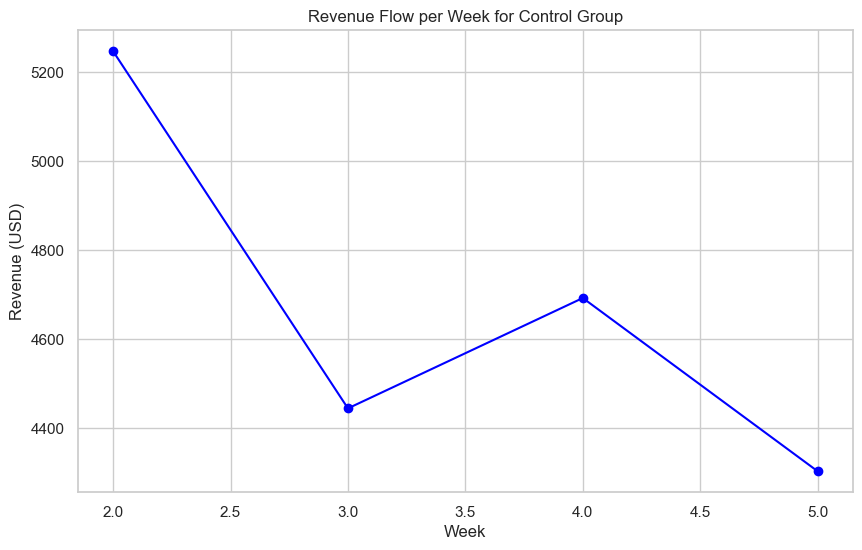

In [129]:
#flow of revenue per week for control group
ab_test['week'] = ab_test['session_date'].dt.isocalendar().week
revenue_by_week_control = ab_test[ab_test['group'] == 'A'].groupby('week')['revenue_usd'].sum()
revenue_by_week_control.plot(kind='line', marker='o', color='blue')
plt.title('Revenue Flow per Week for Control Group')
plt.xlabel('Week')
plt.ylabel('Revenue (USD)')
plt.show()
